In [1]:
# ============================================================
# FUNCTION 2 — WEEK 6
# New clean notebook
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial import cKDTree

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

print("Week 6 Function 2 setup complete")

Week 6 Function 2 setup complete


In [2]:
# ------------------------------------------------------------
# LOAD ORIGINAL DATA
# ------------------------------------------------------------

X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy").reshape(-1)

print("Original X shape:", X.shape)
print("Original Y shape:", Y.shape)


# ------------------------------------------------------------
# ADD WEEKS 1–5 EXACTLY ONCE
# ------------------------------------------------------------

weekly_X = np.array([
    [0.823017, 0.992216],   # Week 1
    [0.706793, 0.934497],   # Week 2
    [0.721184, 0.793590],   # Week 3
    [0.711177, 1.000000],   # Week 4
    [0.643514, 1.000000]    # Week 5
])

weekly_Y = np.array([
    0.06417048162449789,    # Week 1
    0.6557263198296742,     # Week 2
    0.5666392751992081,     # Week 3
    0.6796627330332186,     # Week 4
    0.16167140986094838     # Week 5
])

X = np.vstack([
    X,
    weekly_X
])

Y = np.concatenate([
    Y,
    weekly_Y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("\nWeek 6 training X shape:", X.shape)
print("Week 6 training Y shape:", Y.shape)

print("\nBest observed point:")
print(best_x)

print("Best observed output:")
print(best_y)

print("\nWeek 5 output:", weekly_Y[-1])

Original X shape: (10, 2)
Original Y shape: (10,)

Week 6 training X shape: (15, 2)
Week 6 training Y shape: (15,)

Best observed point:
[0.711177 1.      ]
Best observed output:
0.6796627330332186

Week 5 output: 0.16167140986094838


In [3]:
# ------------------------------------------------------------
# FIT ARD MATERN GAUSSIAN PROCESS
# ------------------------------------------------------------

kernel = (
    C(
        1.0,
        (1e-3, 1e3)
    )
    *
    Matern(
        length_scale=[
            0.05,
            0.20
        ],
        length_scale_bounds=(
            0.005,
            2.0
        ),
        nu=2.5
    )
    +
    WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(
            1e-10,
            1e-2
        )
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=8,
    random_state=62
)

gp.fit(
    X,
    Y
)

print("Fitted kernel:")
print(gp.kernel_)

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

print("\nLengthscales:")
print("x1:", lengthscales[0])
print("x2:", lengthscales[1])

Fitted kernel:
0.896**2 * Matern(length_scale=[0.0255, 1.47], nu=2.5) + WhiteKernel(noise_level=1e-10)

Lengthscales:
x1: 0.025549446553704853
x2: 1.4655656989814332


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [4]:
# ------------------------------------------------------------
# GENERATE WEEK 6 CANDIDATES
# ------------------------------------------------------------

rng = np.random.default_rng(62)

week4_point = np.array([
    0.711177,
    1.000000
])

week2_point = np.array([
    0.706793,
    0.934497
])

# --------------------------------
# A. Very local around Week 4
# --------------------------------

very_local = rng.normal(
    loc=week4_point,
    scale=[
        0.006,
        0.006
    ],
    size=(5000, 2)
)

# --------------------------------
# B. Local search around Week 4
# --------------------------------

local = rng.normal(
    loc=week4_point,
    scale=[
        0.018,
        0.025
    ],
    size=(5000, 2)
)

# --------------------------------
# C. Explicit x2 = 1 boundary
#
# Week 4 performed best here.
# Search x1 carefully around 0.71.
# --------------------------------

boundary_x1 = rng.uniform(
    0.675,
    0.745,
    size=5000
)

boundary = np.column_stack([
    boundary_x1,
    np.ones(5000)
])

# --------------------------------
# D. Near-boundary candidates
# --------------------------------

near_boundary = np.column_stack([
    rng.uniform(
        0.68,
        0.74,
        size=4000
    ),
    rng.uniform(
        0.92,
        1.00,
        size=4000
    )
])

# --------------------------------
# E. Search between Week 2 and Week 4
#
# Both were strong observations.
# --------------------------------

weights = rng.uniform(
    0,
    1,
    size=(3000, 1)
)

between = (
    weights * week2_point
    +
    (1 - weights) * week4_point
)

between += rng.normal(
    0,
    [0.008, 0.012],
    size=(3000, 2)
)

# --------------------------------
# F. Very small wider component
# --------------------------------

wider = np.column_stack([
    rng.uniform(
        0.64,
        0.78,
        size=1500
    ),
    rng.uniform(
        0.80,
        1.00,
        size=1500
    )
])

candidates = np.vstack([
    very_local,
    local,
    boundary,
    near_boundary,
    between,
    wider
])

candidates = np.clip(
    candidates,
    0,
    1
)

print(
    "Candidates before filtering:",
    len(candidates)
)

Candidates before filtering: 23500


In [5]:
# ------------------------------------------------------------
# REMOVE CANDIDATES TOO CLOSE TO EXISTING OBSERVATIONS
# ------------------------------------------------------------

tree = cKDTree(X)

minimum_distance, _ = tree.query(
    candidates,
    k=1
)

candidates = candidates[
    minimum_distance > 0.0015
]

print(
    "Candidates after filtering:",
    len(candidates)
)

Candidates after filtering: 22534


In [6]:
# ------------------------------------------------------------
# GP PREDICTIONS
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)


# ------------------------------------------------------------
# EXPECTED IMPROVEMENT
# ------------------------------------------------------------

xi = 0.001

improvement = (
    mean
    - best_y
    - xi
)

with np.errstate(
    divide="ignore",
    invalid="ignore"
):

    z = improvement / std

    ei = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

ei[std < 1e-12] = 0


# ------------------------------------------------------------
# SMALL UCB COMPONENT
# ------------------------------------------------------------

kappa = 0.35

ucb = mean + kappa * std


# ------------------------------------------------------------
# NORMALISE
# ------------------------------------------------------------

ei_norm = (
    ei - ei.min()
) / (
    np.ptp(ei) + 1e-12
)

ucb_norm = (
    ucb - ucb.min()
) / (
    np.ptp(ucb) + 1e-12
)


# Strong emphasis on exploitation
acquisition = (
    0.88 * ei_norm
    + 0.12 * ucb_norm
)


# ------------------------------------------------------------
# CHOOSE WEEK 6 QUERY
# ------------------------------------------------------------

chosen_index = np.argmax(
    acquisition
)

week6_query = candidates[
    chosen_index
]

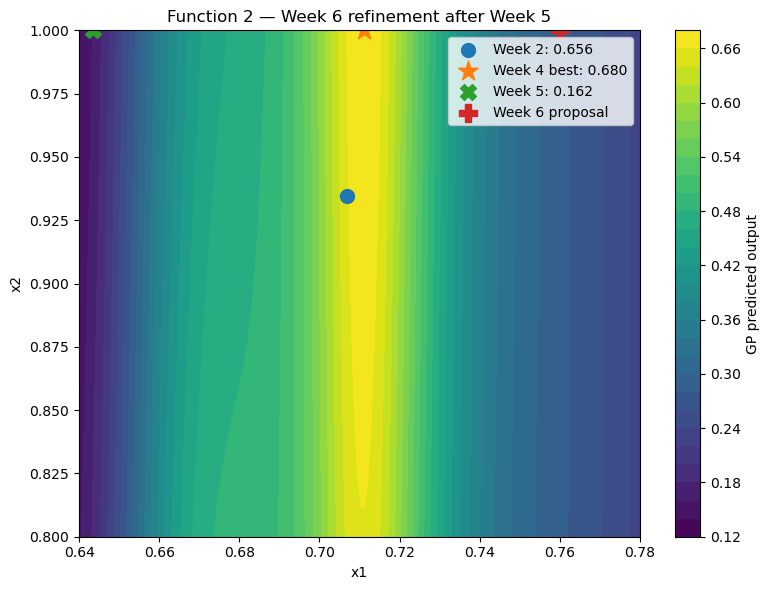

In [7]:
# ============================================================
# FUNCTION 2 — WEEK 6 VISUALISATION
# ============================================================

x1_values = np.linspace(
    0.64,
    0.78,
    170
)

x2_values = np.linspace(
    0.80,
    1.00,
    170
)

X1_grid, X2_grid = np.meshgrid(
    x1_values,
    x2_values
)

grid_points = np.column_stack([
    X1_grid.ravel(),
    X2_grid.ravel()
])

grid_mean, grid_std = gp.predict(
    grid_points,
    return_std=True
)

grid_mean = grid_mean.reshape(
    X1_grid.shape
)

plt.figure(
    figsize=(8, 6)
)

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_mean,
    levels=30
)

plt.colorbar(
    contour,
    label="GP predicted output"
)

# Week 2
plt.scatter(
    0.706793,
    0.934497,
    marker="o",
    s=100,
    label="Week 2: 0.656"
)

# Week 4 best
plt.scatter(
    0.711177,
    1.000000,
    marker="*",
    s=220,
    label="Week 4 best: 0.680"
)

# Week 5 poor result
plt.scatter(
    0.643514,
    1.000000,
    marker="X",
    s=130,
    label="Week 5: 0.162"
)

# Week 6 proposal
plt.scatter(
    week6_query[0],
    week6_query[1],
    marker="P",
    s=180,
    label="Week 6 proposal"
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title(
    "Function 2 — Week 6 refinement after Week 5"
)

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
chosen_index = np.argmax(acquisition)
week6_query = candidates[chosen_index]

In [9]:
# ============================================================
# FUNCTION 2 — WEEK 6 PORTAL OUTPUT
# ============================================================

print("Suggested Week 6 query:")
print(week6_query)

print("\nPortal format:")
print("-".join(f"{value:.6f}" for value in week6_query))

print("\nPredicted mean:", mean[chosen_index])
print("Predicted uncertainty:", std[chosen_index])
print("Expected Improvement:", ei[chosen_index])

print(
    "Distance from Week 4 best:",
    np.linalg.norm(
        week6_query - np.array([0.711177, 1.000000])
    )
)

Suggested Week 6 query:
[0.76009461 1.        ]

Portal format:
0.760095-1.000000

Predicted mean: 0.28699478964811986
Predicted uncertainty: 0.21513364934744555
Expected Improvement: 0.002847666443300541
Distance from Week 4 best: 0.04891760821739555
